In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import davies_bouldin_score
warnings.filterwarnings('ignore')

In [4]:
header = ['area', 'perimeter', 'compactness', 'length', 'width', 'asymmetry_coef', 'groove', 'type']
filename = 'seeds_dataset.txt'

df = pd.read_csv('seeds_dataset.txt', header=None, delim_whitespace=True)
df.columns = header

df.head()

,area,perimeter,compactness,length,width,asymmetry_coef,groove,type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


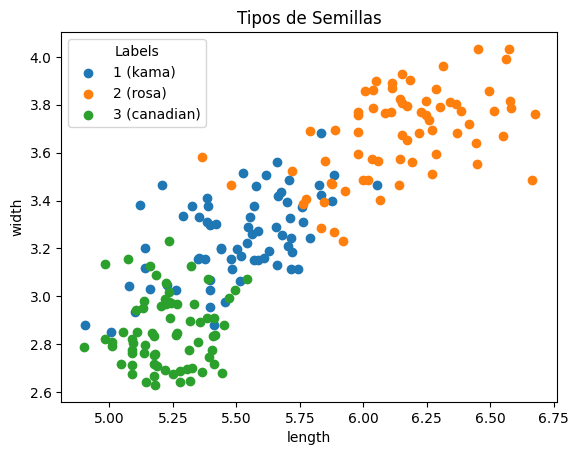

In [27]:
# distribucion de tipos de semillas
plt.scatter(x=df['length'][df['type'] == 1], y=df['width'][df['type'] == 1], label='1 (kama)')
plt.scatter(x=df['length'][df['type'] == 2], y=df['width'][df['type'] == 2], label='2 (rosa)')
plt.scatter(x=df['length'][df['type'] == 3], y=df['width'][df['type'] == 3], label='3 (canadian)')
plt.title('Tipos de Semillas')
plt.xlabel('length')
plt.ylabel('width')
plt.legend(title='Labels')
plt.show()

In [7]:
# X - feature array
# Y - target data
df_kmeans = df.iloc[:, [0, 1, 2, 3, 4, 5, 6]]
Y = df['type']

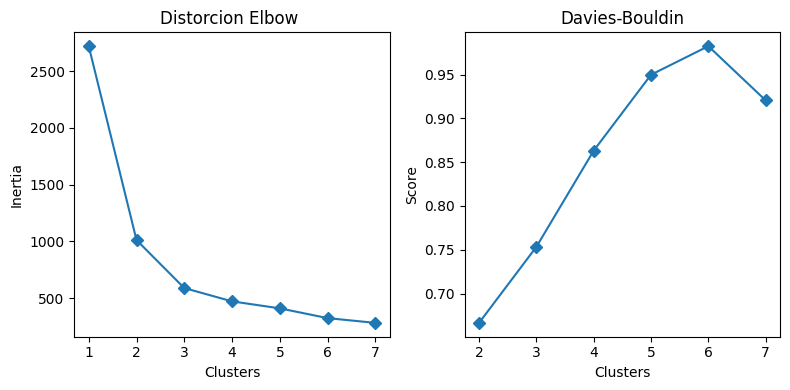

In [39]:
# Usaremos el Elbow Method para definir el numero de clusters
# Elbow
inertias = [] 
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, max_iter=300)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
        
# Metodo Davies-Bouldin
dav_bould_idx = []
for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, max_iter=300)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    dav_bould_idx.append(davies_bouldin_score(X, cluster_labels))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot(range(1, len(inertias)+1), inertias, marker='D')
axes[0].set(title='Distorcion Elbow ', xlabel='Clusters', ylabel='Inertia')

axes[1].plot(range(2, 8), dav_bould_idx, marker='D')
axes[1].set(title='Davies-Bouldin', xlabel='Clusters', ylabel='Score')

plt.tight_layout()
plt.show()


In [41]:
# Esto nos indica que el numero de clusters a usar es 3 y lo usaremos para el resto del ejercicio.


In [10]:
# vamos directo al clustering
from sklearn.cluster import KMeans

# inicializamos
cluster_kmeans = KMeans(n_clusters=3, random_state=42)
model_kmeans = cluster_kmeans.fit(df_kmeans)

# sacamos etiquetas
pred_kmeans = model_kmeans.labels_


In [11]:
# sacamos los clusters centrados en asymetria y area
centroids = cluster_kmeans.cluster_centers_
cen_x = [i[5] for i in centroids]
cen_y = [i[0] for i in centroids]

In [12]:
df_kmeans['cluster'] = pred_kmeans
df_kmeans['cen_x'] = df_kmeans['cluster'].map({0: cen_x[0], 1: cen_x[1], 2: cen_x[2]})
df_kmeans['cen_y'] = df_kmeans['cluster'].map({0: cen_y[0], 1: cen_y[1], 2: cen_y[2]})

# map color per cluster
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
df_kmeans['color'] = df_kmeans['cluster'].map({0: colors[0], 1: colors[1], 2: colors[2]})

df_kmeans.head()


,area,perimeter,compactness,length,width,asymmetry_coef,groove,cluster,cen_x,cen_y,color
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,2,2.648933,14.648472,#2ca02c
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,2,2.648933,14.648472,#2ca02c
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,2,2.648933,14.648472,#2ca02c
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,2,2.648933,14.648472,#2ca02c
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,2,2.648933,14.648472,#2ca02c


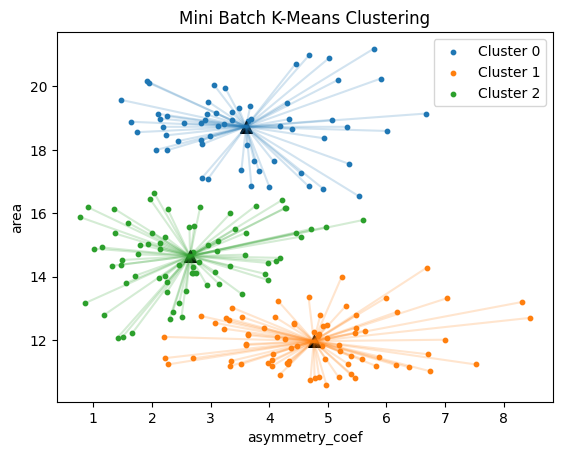

In [28]:
#  visualizamos
plt.scatter(x=df_kmeans['asymmetry_coef'][df_kmeans['cluster'] == 0], y=df_kmeans['area'][df_kmeans['cluster'] == 0],
            s=10, label='Cluster 0')
plt.scatter(x=df_kmeans['asymmetry_coef'][df_kmeans['cluster'] == 1], y=df_kmeans['area'][df_kmeans['cluster'] == 1],
            s=10, label='Cluster 1')
plt.scatter(x=df_kmeans['asymmetry_coef'][df_kmeans['cluster'] == 2], y=df_kmeans['area'][df_kmeans['cluster'] == 2],
            s=10, label='Cluster 2')

# plot lines
for idx, val in df_kmeans.iterrows():
    x = [val.asymmetry_coef, val.cen_x,]
    y = [val.area, val.cen_y]
    plt.plot(x, y, c=val.color, alpha=0.2)

# plot centroids
plt.scatter(cen_x, cen_y, marker='^', c='black', s=70)

plt.title('Mini Batch K-Means Clustering')
plt.xlabel('asymmetry_coef')
plt.ylabel('area')
plt.legend()
plt.show()

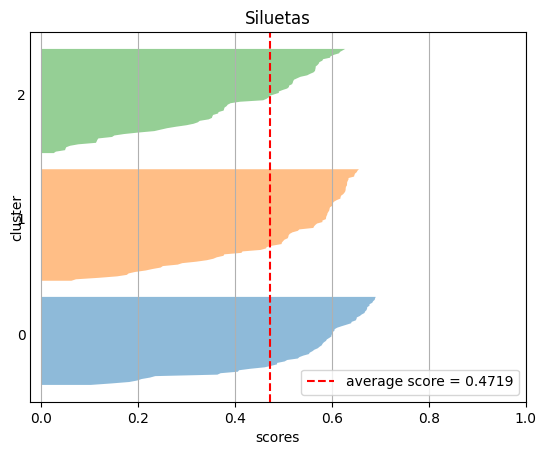

In [30]:
from sklearn.metrics import silhouette_score, silhouette_samples

X = df_kmeans.iloc[:, [0, 1, 2, 3, 4, 5, 6]]

# silueta
silhouette_vals = silhouette_samples(X, pred_kmeans)

y_lower = 0
y_upper = 0
for i in [0, 1, 2]:
    # gagrupamos
    cluster_silhouette_vals = silhouette_vals[pred_kmeans == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(y=np.arange(y_lower, y_upper), x1=0, x2=cluster_silhouette_vals, alpha=0.5, edgecolor=None)
    
    # ponemos la etiqueta en medio
    plt.text(x=-0.05, y=(y_lower + y_upper) / 2, s=str(i))
    # new y_lower for next plot
    y_lower = y_upper + 10

# ploteamso el promedio de las siluetas
avg_score = (silhouette_vals).mean()
plt.axvline(x=avg_score, ls='--', color='red', label='average score = {:.4f}'.format(avg_score))
plt.yticks([])
plt.xlim([silhouette_vals.min() - 0.05, 1])
plt.title('Siluetas')
plt.xlabel('scores')
plt.ylabel('cluster')
plt.grid(axis='x')
plt.legend()
plt.show()

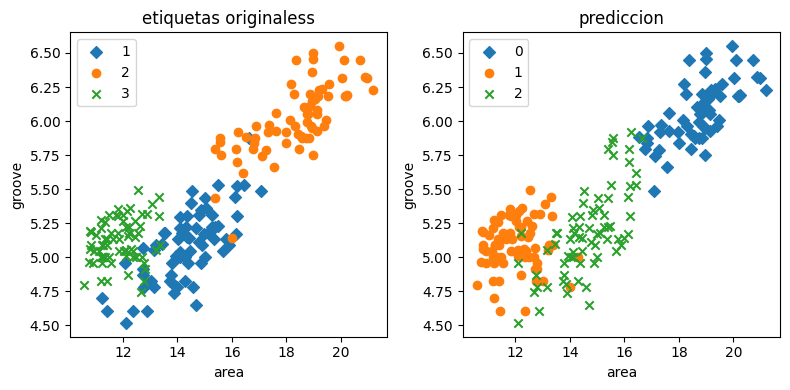

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(x=df['area'][df['type'] == 1], y=df['groove'][df['type'] == 1], marker='D', label='1')
axes[0].scatter(x=df['area'][df['type'] == 2], y=df['groove'][df['type'] == 2], label='2')
axes[0].scatter(x=df['area'][df['type'] == 3], y=df['groove'][df['type'] == 3], marker='x', label='3')
axes[0].set(title='etiquetas originaless', xlabel='area', ylabel='groove')
axes[0].legend()

axes[1].scatter(x=df_kmeans['area'][df_kmeans['cluster'] == 0], y=df_kmeans['groove'][df_kmeans['cluster'] == 0],
                marker='D', label='0')
axes[1].scatter(x=df_kmeans['area'][df_kmeans['cluster'] == 1], y=df_kmeans['groove'][df_kmeans['cluster'] == 1], label='1')
axes[1].scatter(x=df_kmeans['area'][df_kmeans['cluster'] == 2], y=df_kmeans['groove'][df_kmeans['cluster'] == 2],
                marker='x', label='2')
axes[1].set(title='prediccion', xlabel='area', ylabel='groove')
axes[1].legend()

plt.tight_layout()
plt.show()

In [58]:
from sklearn.metrics import calinski_harabasz_score, rand_score, mutual_info_score, homogeneity_score, completeness_score

print('Etiquetas Originales:')
print(df['type'].value_counts())
print('-' * 30)
print('Predicciones:')
print(df_kmeans['cluster'].value_counts())

print('\nMetricas:')
print('-' * 30)
print('Davies-Bouldin:', round(davies_bouldin_score(X, pred_kmeans), 4))
print('Caliński-Harabiasz:', round(calinski_harabasz_score(X, pred_kmeans), 4))
print('Adjusted Rand Index:', round(rand_score(Y, pred_kmeans), 4))
print('Adjusted Mutual Information:', round(mutual_info_score(Y, pred_kmeans), 4))
print('Homogeneity:', round(homogeneity_score(Y, pred_kmeans), 4))
print('Completness:', round(completeness_score(Y, pred_kmeans), 4))

Etiquetas Originales:
type
1    70
2    70
3    70
Name: count, dtype: int64
------------------------------
Predicciones:
cluster
1    77
2    72
0    61
Name: count, dtype: int64

Metricas:
------------------------------
Davies-Bouldin: 0.7533
Caliński-Harabiasz: 375.805
Adjusted Rand Index: 0.8744
Adjusted Mutual Information: 0.7618
Homogeneity: 0.6935
Completness: 0.6964


In [22]:
# Aglomeraciones (Jerarquicas)
from sklearn.cluster import AgglomerativeClustering

cluster_agglo = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='average')  
model_agglo = cluster_agglo.fit(X)

pred_agglo = model_agglo.labels_
pred_agglo


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
# hacemos una copia de la data observada
df_agglo = df.iloc[:, 0:7].copy()

# agregamos la etiqueta para la aglomeracion
df_agglo['cluster'] = pred_agglo

# le ponemos colores
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
df_agglo['color'] = df_agglo['cluster'].map({0: colors[0], 1: colors[1], 2: colors[2]})

df_agglo.head()


,area,perimeter,compactness,length,width,asymmetry_coef,groove,cluster,color
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,2,#2ca02c
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,2,#2ca02c
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,2,#2ca02c
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,2,#2ca02c
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,2,#2ca02c


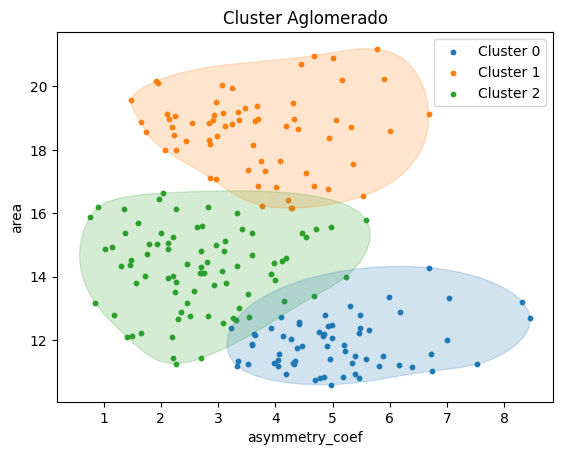

In [34]:
# veamos que nos queda!
from scipy.spatial import ConvexHull
from scipy import interpolate

plt.scatter(x=df_agglo['asymmetry_coef'][df_agglo['cluster'] == 0], y=df_agglo['area'][df_agglo['cluster'] == 0], s=10, label='Cluster 0')
plt.scatter(x=df_agglo['asymmetry_coef'][df_agglo['cluster'] == 1], y=df_agglo['area'][df_agglo['cluster'] == 1], s=10, label='Cluster 1')
plt.scatter(x=df_agglo['asymmetry_coef'][df_agglo['cluster'] == 2], y=df_agglo['area'][df_agglo['cluster'] == 2], s=10, label='Cluster 2')

# margenes
for i in df_agglo['cluster'].unique():
    # get the convex hull
    points = df_agglo[df_agglo['cluster'] == i][['asymmetry_coef', 'area']].values
    hull = ConvexHull(points)
    x_hull = np.append(points[hull.vertices, 0], points[hull.vertices, 0][0])
    y_hull = np.append(points[hull.vertices, 1], points[hull.vertices, 1][0])
    
    # interpolate
    dist = np.sqrt((x_hull[:-1] - x_hull[1:])**2 + (y_hull[:-1] - y_hull[1:])**2)
    dist_along = np.concatenate(([0], dist.cumsum()))
    spline, u = interpolate.splprep([x_hull, y_hull], u=dist_along, s=0, per=1)
    interp_d = np.linspace(dist_along[0], dist_along[-1], 50)
    interp_x, interp_y = interpolate.splev(interp_d, spline)
    
    # plot shape
    plt.fill(interp_x, interp_y, '--', c=colors[i], alpha=0.2)

plt.title('Cluster Aglomerado')
plt.xlabel('asymmetry_coef')
plt.ylabel('area')
plt.legend()
plt.show()

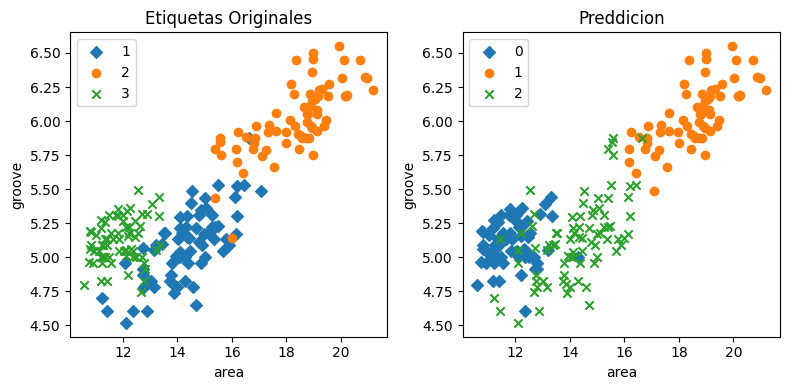

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(x=df['area'][df['type'] == 1], y=df['groove'][df['type'] == 1], marker='D', label='1')
axes[0].scatter(x=df['area'][df['type'] == 2], y=df['groove'][df['type'] == 2], label='2')
axes[0].scatter(x=df['area'][df['type'] == 3], y=df['groove'][df['type'] == 3], marker='x', label='3')
axes[0].set(title='Etiquetas Originales', xlabel='area', ylabel='groove')
axes[0].legend()

axes[1].scatter(x=df_agglo['area'][df_agglo['cluster'] == 0], y=df_agglo['groove'][df_agglo['cluster'] == 0], marker='D', label='0')
axes[1].scatter(x=df_agglo['area'][df_agglo['cluster'] == 1], y=df_agglo['groove'][df_agglo['cluster'] == 1], label='1')
axes[1].scatter(x=df_agglo['area'][df_agglo['cluster'] == 2], y=df_agglo['groove'][df_agglo['cluster'] == 2], marker='x', label='2')
axes[1].set(title='Preddicion', xlabel='area', ylabel='groove')
axes[1].legend()

plt.tight_layout()
plt.show()

In [59]:
print('Etiquetas Originales:')
print(df['type'].value_counts())
print('-' * 30)
print('Predicciones:')
print(df_agglo['cluster'].value_counts())

print('\nMetricas:')
print('-' * 30)
print('Davies-Bouldin:', round(davies_bouldin_score(X, pred_agglo), 4))
print('Caliński-Harabiasz:', round(calinski_harabasz_score(X, pred_agglo), 4))
print('Adjusted Rand Index:', round(rand_score(Y, pred_agglo), 4))
print('Adjusted Mutual Information:', round(mutual_info_score(Y, pred_agglo), 4))
print('Homogeneity:', round(homogeneity_score(Y, pred_agglo), 4))
print('Completness:', round(completeness_score(Y, pred_agglo), 4))

Etiquetas Originales:
type
1    70
2    70
3    70
Name: count, dtype: int64
------------------------------
Predicciones:
cluster
2    81
1    65
0    64
Name: count, dtype: int64

Metricas:
------------------------------
Davies-Bouldin: 0.7604
Caliński-Harabiasz: 355.2366
Adjusted Rand Index: 0.8865
Adjusted Mutual Information: 0.7835
Homogeneity: 0.7131
Completness: 0.7171


In [42]:
# DBSCAN Clustering 
from sklearn.preprocessing import StandardScaler

X_ = np.array(df.iloc[:, [0, 1, 2, 3, 4, 5, 6]])

# X - feature array -- estandarizamos
# Y - target data
df_scan = StandardScaler().fit_transform(X_)
Y = df['type']

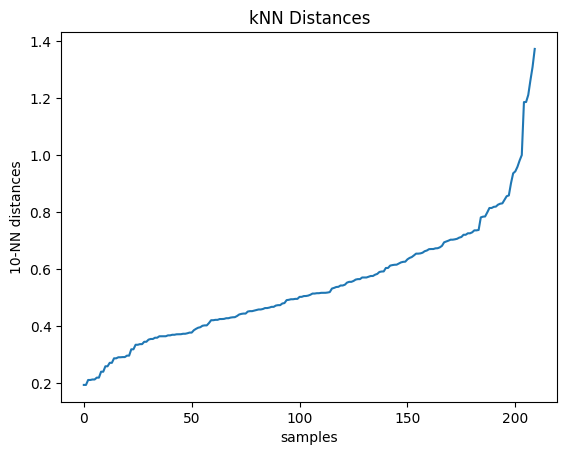

In [44]:
# determinamos hyperparametros con ELbow Method
from sklearn.neighbors import NearestNeighbors

nn_neighbors = 10
nn_model = NearestNeighbors(n_neighbors=nn_neighbors).fit(df_scan)
distances_, indices = nn_model.kneighbors(df_scan)

distances = np.sort(distances_, axis=0)
nn_distances = distances[:, 1]

# elbow plot para epsilon optimo
plt.plot(nn_distances)
plt.title('kNN Distances')
plt.xlabel('samples')
plt.ylabel('{}-NN distances'.format(nn_neighbors))
plt.show()

In [45]:
# Basados en el grafico usaremos un epsilon entre 0.7 y 1.0 como valor optimo

In [46]:
from sklearn.cluster import DBSCAN

# epsilon & min. para investigar
eps_values_ = np.arange(0.7, 1.0, 0.05)
eps_values = np.around(eps_values_, decimals=2)
min_samples = range(2, 21)

# lista de parametros para DBSCAN 
dbscan_params = []
for eps_value in eps_values:
    for min_sample in min_samples:
        dbscan_params.append((eps_value, min_sample))


num_clusters = []
sil_score = []
for p in dbscan_params:
    dbs_clustering = DBSCAN(eps=p[0], min_samples=p[1]).fit(df_scan)
    num_clusters.append(len(np.unique(dbs_clustering.labels_)))
    try:
        sil_score.append(silhouette_score(df_scan, dbs_clustering.labels_))
    except:
        sil_score.append(0.00)

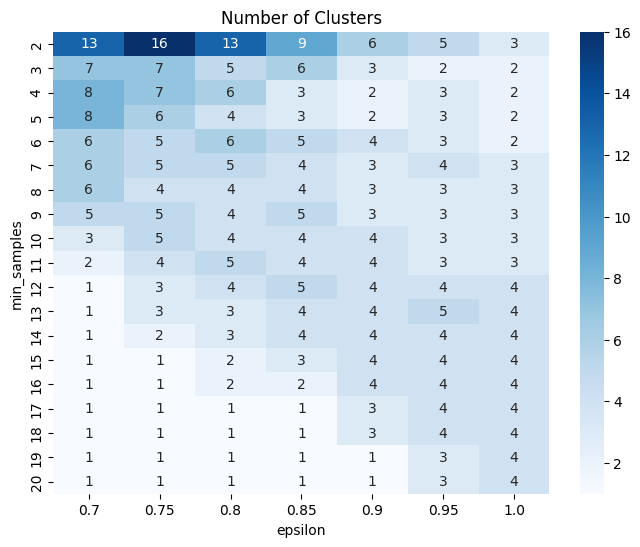

In [47]:
# y aqui el famoso heatmap :P
from seaborn import heatmap

tmp = pd.DataFrame.from_records(data=dbscan_params, columns=['epsilon', 'min_samples'])   
tmp['num_clusters'] = num_clusters
tmp['sil_score'] = sil_score

# tabla con el numero de clusters
pivot_clus = pd.pivot_table(tmp, values='num_clusters', index='min_samples', columns='epsilon')

plt.figure(figsize=(8, 6))
heatmap(pivot_clus, annot=True, cmap='Blues')
plt.title('Numero de Clusters')
plt.show()

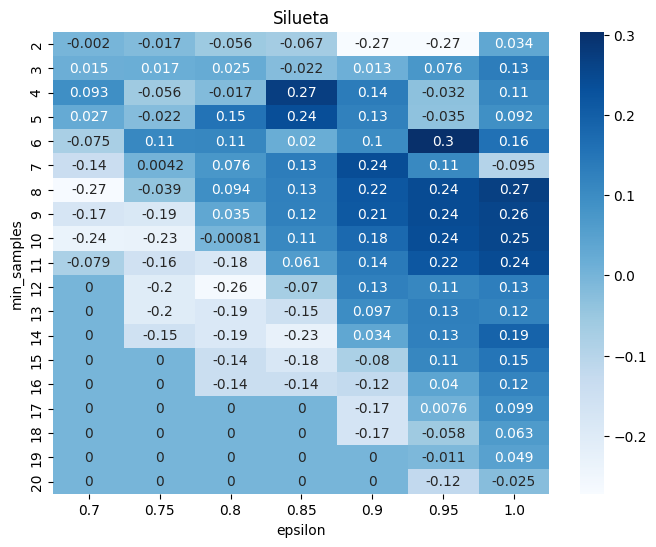

Parametros optimos:
epsilon = 0.95
muestra minima = 6


In [49]:
# tabla con los puntajes de la silueta
pivot_sil = pd.pivot_table(tmp, values='sil_score', index='min_samples', columns='epsilon')

plt.figure(figsize=(8, 6))
heatmap(pivot_sil, annot=True, cmap='Blues')
plt.title('Silueta')
plt.show()

print('Parametros optimos:\nepsilon = {:.2}\nmuestra minima = {}'.format(pivot_sil.max(axis=0).idxmax(),
                                                                          pivot_sil.max(axis=1).idxmax()))

In [50]:
# ya con esto vamos al clustering con DBSCAN
cluster_scan = DBSCAN(eps=0.95, min_samples=6)
model_scan = cluster_scan.fit(df_scan)

# etiqueta por instancia
pred_scan = model_scan.labels_
pred_scan

array([ 0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  0,  0,  0,  0,  0, -1, -1,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0,  0,
        0,  0,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  0,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  0,
        1, -1, -1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0, -1,  0,  0])

In [52]:
# si nos fijamos solo hay -1, 0 y 1, los mismos 3 clusters que vimos anteriormente.
# procedemos al cluster

In [53]:
df_dbscan = pd.DataFrame(df_scan)
df_dbscan.columns = ['area', 'perimeter', 'compactness', 'length', 'width', 'asymmetry_coef', 'groove']
df_dbscan['cluster'] = pred_scan

# map color per cluster
colors = ['red', '#1f77b4', '#ff7f0e']
df_dbscan['color'] = df_dbscan['cluster'].map({-1: colors[0], 0: colors[1], 1: colors[2]})

df_dbscan.head()

,area,perimeter,compactness,length,width,asymmetry_coef,groove,cluster,color
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577,0,#1f77b4
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013,0,#1f77b4
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192,0,#1f77b4
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983,0,#1f77b4
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356,0,#1f77b4


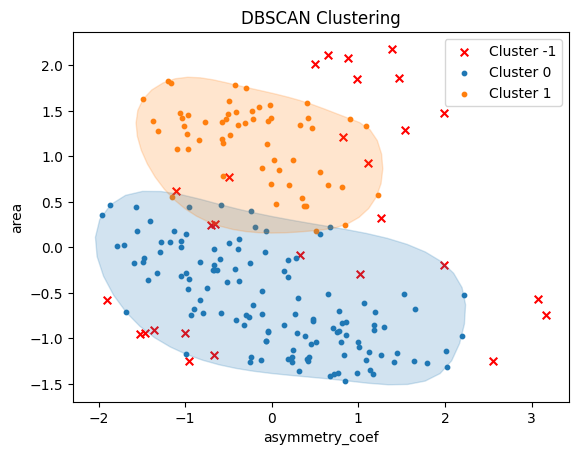

In [54]:
plt.scatter(x=df_dbscan['asymmetry_coef'][df_dbscan['cluster'] == -1], y=df_dbscan['area'][df_dbscan['cluster'] == -1],
            color='red', marker='x', s=30, label='Cluster -1')
plt.scatter(x=df_dbscan['asymmetry_coef'][df_dbscan['cluster'] == 0], y=df_dbscan['area'][df_dbscan['cluster'] == 0],
            s=10, label='Cluster 0')
plt.scatter(x=df_dbscan['asymmetry_coef'][df_dbscan['cluster'] == 1], y=df_dbscan['area'][df_dbscan['cluster'] == 1],
            s=10, label='Cluster 1')

# plot boundaries
for i in [0, 1]:
    # get the convex hull
    points = df_dbscan[df_dbscan['cluster'] == i][['asymmetry_coef', 'area']].values
    hull = ConvexHull(points)
    x_hull = np.append(points[hull.vertices, 0], points[hull.vertices, 0][0])
    y_hull = np.append(points[hull.vertices, 1], points[hull.vertices, 1][0])
    
    # interpolate
    dist = np.sqrt((x_hull[:-1] - x_hull[1:])**2 + (y_hull[:-1] - y_hull[1:])**2)
    dist_along = np.concatenate(([0], dist.cumsum()))
    spline, u = interpolate.splprep([x_hull, y_hull], u=dist_along, s=0, per=1)
    interp_d = np.linspace(dist_along[0], dist_along[-1], 50)
    interp_x, interp_y = interpolate.splev(interp_d, spline)
    
    # plot shape
    plt.fill(interp_x, interp_y, '--', c=colors[i+1], alpha=0.2)

plt.title('DBSCAN Clustering')
plt.xlabel('asymmetry_coef')
plt.ylabel('area')
plt.legend()
plt.show()

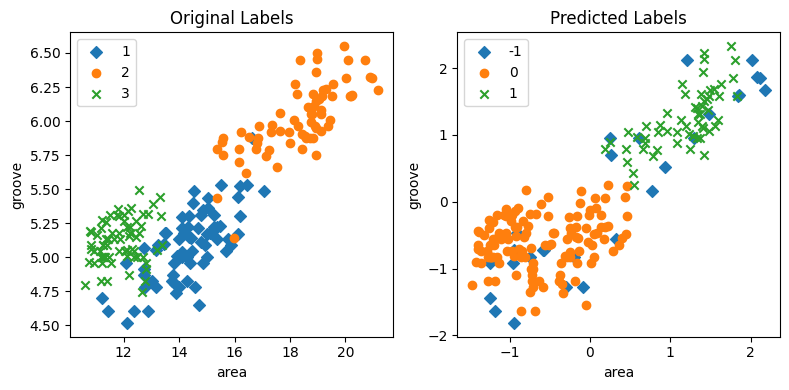

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(x=df['area'][df['type'] == 1], y=df['groove'][df['type'] == 1], marker='D', label='1')
axes[0].scatter(x=df['area'][df['type'] == 2], y=df['groove'][df['type'] == 2], label='2')
axes[0].scatter(x=df['area'][df['type'] == 3], y=df['groove'][df['type'] == 3], marker='x', label='3')
axes[0].set(title='Original Labels', xlabel='area', ylabel='groove')
axes[0].legend()

axes[1].scatter(x=df_dbscan['area'][df_dbscan['cluster'] == -1], y=df_dbscan['groove'][df_dbscan['cluster'] == -1],
                marker='D', label='-1')
axes[1].scatter(x=df_dbscan['area'][df_dbscan['cluster'] == 0], y=df_dbscan['groove'][df_dbscan['cluster'] == 0], label='0')
axes[1].scatter(x=df_dbscan['area'][df_dbscan['cluster'] == 1], y=df_dbscan['groove'][df_dbscan['cluster'] == 1], marker='x',
                label='1')
axes[1].set(title='Predicted Labels', xlabel='area', ylabel='groove')
axes[1].legend()

plt.tight_layout()
plt.show()

In [57]:
# mostramos los resultados
print('Original labels:')
print(df['type'].value_counts())
print('-' * 30)
print('Predicted labels:')
print(df_dbscan['cluster'].value_counts())

print('\nPerformance metrics:')
print('-' * 30)
print('Davies-Bouldin:', round(davies_bouldin_score(X, pred_scan), 4))
print('Caliński-Harabiasz:', round(calinski_harabasz_score(X, pred_scan), 4))
print('Adjusted Rand Index:', round(rand_score(Y, pred_scan), 4))
print('Adjusted Mutual Information:', round(mutual_info_score(Y, pred_scan), 4))
print('Homogeneity:', round(homogeneity_score(Y, pred_scan), 4))
print('Completness:', round(completeness_score(Y, pred_scan), 4))

Original labels:
type
1    70
2    70
3    70
Name: count, dtype: int64
------------------------------
Predicted labels:
cluster
 0    125
 1     57
-1     28
Name: count, dtype: int64

Performance metrics:
------------------------------
Davies-Bouldin: 1.9598
Caliński-Harabiasz: 106.1041
Adjusted Rand Index: 0.7193
Adjusted Mutual Information: 0.4824
Homogeneity: 0.4391
Completness: 0.5179


In [62]:
# vamos a comparar el rendimiento de los distintos metodos de clustering
# metric lists
kmeans_scores = []
agglo_scores = []
dbscan_scores = []

predictions = [pred_kmeans, pred_agglo, pred_scan]
score_list = [kmeans_scores, agglo_scores, dbscan_scores]

# nueva lista por algoritmo
for pred, ls in zip(predictions, score_list):
    ls.append(silhouette_score(X, pred))
    ls.append(davies_bouldin_score(X, pred))
    ls.append(calinski_harabasz_score(X, pred))
    ls.append(rand_score(Y, pred))
    ls.append(mutual_info_score(Y, pred))
    ls.append(homogeneity_score(Y, pred))
    ls.append(completeness_score(Y, pred))
    
# Puntajes de validacion
metrics = pd.DataFrame.from_records(data=[kmeans_scores, agglo_scores, dbscan_scores],
                    columns=['Silhouette', 'Davies-Bouldin', 'Caliński-Harabasz', 'ARI', 'AMI', 'Homogeneity', 'Completeness'],
                    index=['Mini Batch K-Means', 'Agglomerative', 'DBSCAN'])

# destacamos las funciones
def highlight_max(s):
    is_max = s == s.max()
    return ['background: gold' if cell else '' for cell in is_max]

def highlight_min(s):
    is_min = s == s.min()
    return ['background: gold' if cell else '' for cell in is_min]

# destcamaos los puntajes optimos
metric_ = metrics.style.apply(highlight_max,
                    subset=pd.IndexSlice[:, ['Silhouette', 'Caliński-Harabasz', 'ARI', 'AMI', 'Homogeneity', 'Completeness']])
metric_.apply(highlight_min, subset=pd.IndexSlice[:, ['Davies-Bouldin']])

,Silhouette,Davies-Bouldin,Caliński-Harabasz,ARI,AMI,Homogeneity,Completeness
Mini Batch K-Means,0.471934,0.753314,375.804961,0.874368,0.761844,0.693461,0.696396
Agglomerative,0.458112,0.760425,355.236643,0.886489,0.783452,0.713129,0.717076
DBSCAN,0.348390,1.959814,106.104116,0.719344,0.482398,0.439097,0.517918
